In [13]:
import scanpy as sc
import os
import anndata
import pandas as pd

path = "/home/arism/datasets/raw_data/batch_0.h5ad"


# Concatenate into one big AnnData object
adata = sc.read_h5ad(path)


import gc
gc.collect()


1318

In [14]:
import mygene

# Initialize MyGeneInfo
mg = mygene.MyGeneInfo()

# Convert Ensembl IDs to gene symbols
ensembl_ids = adata.var['ensembl_id'].tolist()

# Query mygene
results = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human')

# Build a mapping from Ensembl ID to gene symbol
id_to_symbol = {res['query']: res.get('symbol', '') for res in results}

# Create new column in adata.var with gene symbols
adata.var['gene_symbol'] = adata.var['ensembl_id'].map(id_to_symbol)

adata.var.index = adata.var['gene_symbol']

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
35 input query terms found dup hits:	[('ENSG00000278932', 3), ('ENSG00000188660', 2), ('ENSG00000226506', 2), ('ENSG00000226519', 2), ('E
1146 input query terms found no hit:	['ENSG00000272583', 'ENSG00000240401', 'ENSG00000270019', 'ENSG00000223797', 'ENSG00000272146', 'ENS


In [15]:
print(adata.var.head(5))

             soma_joinid       feature_id       feature_name    feature_type  \
gene_symbol                                                                    
LINC01409              0  ENSG00000237491          LINC01409          lncRNA   
NOC2L                  1  ENSG00000188976              NOC2L  protein_coding   
PERM1                  2  ENSG00000187642              PERM1  protein_coding   
                       3  ENSG00000272512  ENSG00000272512.1          lncRNA   
HES4                   4  ENSG00000188290               HES4  protein_coding   

             feature_length       nnz  n_measured_obs       ensembl_id  \
gene_symbol                                                              
LINC01409              1059   7958785        92252850  ENSG00000237491   
NOC2L                  1244  18685092       105784525  ENSG00000188976   
PERM1                  2765    664016        95688802  ENSG00000187642   
                       2086    927207        91649589  ENSG0000027251

In [16]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=40000, flavor="seurat")
adata = adata[:, adata.var.highly_variable]

In [17]:
print(adata.shape)
import gc
gc.collect()

(309999, 40000)


294

In [ ]:
print(adata.var.columns)

Index(['soma_joinid', 'feature_id', 'feature_name', 'feature_type',
       'feature_length', 'nnz', 'n_measured_obs', 'ensembl_id', 'gene_symbol',
       'highly_variable', 'means', 'dispersions', 'dispersions_norm'],
      dtype='object')


In [19]:
from pyscenic.aucell import GeneSignature, create_rankings, enrichment
import pandas as pd
import numpy as np

# Load gene signatures
GMT_FNAME = "/home/arism/cell2text/data_preprocess/h.all.v2025.1.Hs.symbols.gmt"
signatures = GeneSignature.from_gmt(GMT_FNAME, field_separator="\t")

# Convert adata.X to float32 dense matrix (saves 50% memory)
print("Creating expression matrix...")
ex_matrix = pd.DataFrame(
    adata.X.astype(np.float32).toarray(),
    index=adata.obs_names,
    columns=adata.var_names
)

# Parameters
chunk_size = 20000  # Adjust based on your memory budget
n_chunks = int(np.ceil(ex_matrix.shape[0] / chunk_size))

# Prepare result container
all_aucs = []
signature_names = [sig.name for sig in signatures]

print("Processing in chunks...")
for i in range(n_chunks):
    print(f"Processing chunk {i+1}/{n_chunks}")
    chunk = ex_matrix.iloc[i*chunk_size:(i+1)*chunk_size]

    # Create rankings
    rnk_chunk = create_rankings(chunk)

    # Calculate AUCs for this chunk
    chunk_aucs = []
    for signature in signatures:
        auc_scores = enrichment(rnk_chunk, signature)
        chunk_aucs.append(auc_scores)
    
    # Stack into array and add to list
    chunk_aucs = np.column_stack(chunk_aucs)  # shape: (n_cells_chunk, n_signatures)
    all_aucs.append(chunk_aucs)

# Combine all chunks into one big array
print("Combining results...")
final_auc_array = np.vstack(all_aucs)  # shape: (n_total_cells, n_signatures)

# Create final DataFrame
aucs_df = pd.DataFrame(
    final_auc_array,
    index=ex_matrix.index,
    columns=signature_names
)

print("AUC DataFrame:")
print(aucs_df)


Creating expression matrix...


Processing in chunks...
Processing chunk 1/16


Less than 80% of the genes in HALLMARK_ADIPOGENESIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_ANDROGEN_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_APOPTOSIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_CHOLESTEROL_HOMEOSTASIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_DNA_REPAIR are present in the expression matrix.
Less than 80% of the genes in HALLMARK_E2F_TARGETS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_FATTY_ACID_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_G2M_CHECKPOINT are present in the expression matrix.
Less than 80% of the genes in HALLMARK_HEME_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_INTERFERON_ALPHA_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_MITOTIC_SPINDLE are pres

Processing chunk 2/16


Less than 80% of the genes in HALLMARK_ADIPOGENESIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_ANDROGEN_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_APOPTOSIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_CHOLESTEROL_HOMEOSTASIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_DNA_REPAIR are present in the expression matrix.
Less than 80% of the genes in HALLMARK_E2F_TARGETS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_FATTY_ACID_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_G2M_CHECKPOINT are present in the expression matrix.
Less than 80% of the genes in HALLMARK_HEME_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_INTERFERON_ALPHA_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_MITOTIC_SPINDLE are pres

...

Processing chunk 15/16


Less than 80% of the genes in HALLMARK_ADIPOGENESIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_ANDROGEN_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_APOPTOSIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_CHOLESTEROL_HOMEOSTASIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_DNA_REPAIR are present in the expression matrix.
Less than 80% of the genes in HALLMARK_E2F_TARGETS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_FATTY_ACID_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_G2M_CHECKPOINT are present in the expression matrix.
Less than 80% of the genes in HALLMARK_HEME_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_INTERFERON_ALPHA_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_MITOTIC_SPINDLE are pres

Processing chunk 16/16


Less than 80% of the genes in HALLMARK_ADIPOGENESIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_ANDROGEN_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_APOPTOSIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_CHOLESTEROL_HOMEOSTASIS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_DNA_REPAIR are present in the expression matrix.
Less than 80% of the genes in HALLMARK_E2F_TARGETS are present in the expression matrix.
Less than 80% of the genes in HALLMARK_FATTY_ACID_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_G2M_CHECKPOINT are present in the expression matrix.
Less than 80% of the genes in HALLMARK_HEME_METABOLISM are present in the expression matrix.
Less than 80% of the genes in HALLMARK_INTERFERON_ALPHA_RESPONSE are present in the expression matrix.
Less than 80% of the genes in HALLMARK_MITOTIC_SPINDLE are pres

Combining results...
AUC DataFrame:
        HALLMARK_ADIPOGENESIS  HALLMARK_ALLOGRAFT_REJECTION  \
0                         0.0                      0.143311   
1                         0.0                      0.100689   
2                         0.0                      0.120369   
3                         0.0                      0.084387   
4                         0.0                      0.114851   
...                       ...                           ...   
309994                    0.0                      0.030921   
309995                    0.0                      0.018905   
309996                    0.0                      0.031451   
309997                    0.0                      0.025311   
309998                    0.0                      0.022125   

        HALLMARK_ANDROGEN_RESPONSE  HALLMARK_ANGIOGENESIS  \
0                              0.0               0.022206   
1                              0.0               0.018235   
2                       

In [20]:
print(aucs_df)

        HALLMARK_ADIPOGENESIS  HALLMARK_ALLOGRAFT_REJECTION  \
0                         0.0                      0.143311   
1                         0.0                      0.100689   
2                         0.0                      0.120369   
3                         0.0                      0.084387   
4                         0.0                      0.114851   
...                       ...                           ...   
309994                    0.0                      0.030921   
309995                    0.0                      0.018905   
309996                    0.0                      0.031451   
309997                    0.0                      0.025311   
309998                    0.0                      0.022125   

        HALLMARK_ANDROGEN_RESPONSE  HALLMARK_ANGIOGENESIS  \
0                              0.0               0.022206   
1                              0.0               0.018235   
2                              0.0               0.046574   

In [21]:

# Filter pathways that appear in top 5% of >0.5% of cells
top5_percentile_mask = aucs_df.apply(lambda row: row >= np.percentile(row, 95), axis=1)
pathway_frequencies = top5_percentile_mask.sum(axis=0) / top5_percentile_mask.shape[0]
selected_pathways = pathway_frequencies[pathway_frequencies > 0.005].index

# Final filtered AUCell matrix
filtered_aucs = aucs_df[selected_pathways]

# Store in AnnData object
adata.obsm["AUCell_scores_filtered"] = filtered_aucs.loc[adata.obs_names]

/tmp/ipykernel_1928530/129367736.py:10: ImplicitModificationWarning: Setting element `.obsm['AUCell_scores_filtered']` of view, initializing view as actual.
  adata.obsm["AUCell_scores_filtered"] = filtered_aucs.loc[adata.obs_names]
/home/arism/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [22]:
print(len(selected_pathways))

27


In [23]:
print(adata.obsm["AUCell_scores_filtered"])

        HALLMARK_ALLOGRAFT_REJECTION  HALLMARK_ANGIOGENESIS  \
0                           0.143311               0.022206   
1                           0.100689               0.018235   
2                           0.120369               0.046574   
3                           0.084387               0.025735   
4                           0.114851               0.018235   
...                              ...                    ...   
309994                      0.030921               0.059382   
309995                      0.018905               0.027176   
309996                      0.031451               0.051809   
309997                      0.025311               0.063574   
309998                      0.022125               0.083353   

        HALLMARK_APICAL_JUNCTION  HALLMARK_APICAL_SURFACE  \
0                       0.044489                 0.079175   
1                       0.071391                 0.058475   
2                       0.058103                 0.055337   

In [24]:
# --- Add "pathway1" (most active) to adata.obs ---
# Find the pathway with the maximum score for each cell
adata.obs["pathway1"] = aucs_df.idxmax(axis=1)

# --- Add "pathway2" (second most active) to adata.obs ---
# Define a function to get the second largest pathway name (index) for a given row (cell)
def get_second_largest_pathway_name(row):
    # Sort the row values in descending order and get the index (pathway names)
    sorted_pathways = row.sort_values(ascending=False).index

    # If there are at least two pathways, return the second one
    if len(sorted_pathways) >= 2:
        return sorted_pathways[1]
    else:
        # Return a placeholder for cells that don't have a second pathway
        # (e.g., if a cell only has one non-zero pathway score, or fewer than 2 pathways overall)
        return np.nan

# Apply this function across each row (cell) to get the second most active pathway
adata.obs["pathway2"] = aucs_df.apply(get_second_largest_pathway_name, axis=1)

# --- Optional: Fill NaN values if some cells didn't have a second pathway ---
# If you prefer 'N/A' or another string instead of NaN for better readability
adata.obs["pathway2"] = adata.obs["pathway2"].fillna("No_Second_Pathway")


print("\n--- Updated adata.obs (first 5 rows and new columns) ---")
print(adata.obs.head())


--- Updated adata.obs (first 5 rows and new columns) ---
   soma_joinid   sex tissue donor_id                            dataset_id  \
0         5845  male  blood     CVID  a5d95a42-0137-496f-8a60-101e17f263c8   
1         5879  male  blood  CONTROL  a5d95a42-0137-496f-8a60-101e17f263c8   
2         5923  male  blood  CONTROL  a5d95a42-0137-496f-8a60-101e17f263c8   
3         6057  male  blood  CONTROL  a5d95a42-0137-496f-8a60-101e17f263c8   
4         6140  male  blood     CVID  a5d95a42-0137-496f-8a60-101e17f263c8   

  tissue_ontology_term_id tissue_general tissue_general_ontology_term_id  \
0          UBERON:0000178          blood                  UBERON:0000178   
1          UBERON:0000178          blood                  UBERON:0000178   
2          UBERON:0000178          blood                  UBERON:0000178   
3          UBERON:0000178          blood                  UBERON:0000178   
4          UBERON:0000178          blood                  UBERON:0000178   

                

In [27]:
print(adata.var.columns)  # Check all columns in var
print(adata.var.index.name)  # Check the name of the index


Index(['soma_joinid', 'feature_id', 'feature_name', 'feature_type',
       'feature_length', 'nnz', 'n_measured_obs', 'ensembl_id', 'gene_symbol',
       'highly_variable', 'means', 'dispersions', 'dispersions_norm'],
      dtype='object')
gene_symbol


In [28]:
adata.var.index.name = 'var_index'


In [ ]:
output_filename = "/home/arism/datasets/raw_data/adata_with_pathway_info.h5ad"
adata.write(output_filename)


The second most popular pathway (as the most active for cells) is: 'HALLMARK_HEDGEHOG_SIGNALING' with 40370 cells.


/tmp/ipykernel_1928530/2374574550.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=most_active_pathways, order=pathway_counts.index, palette='viridis')


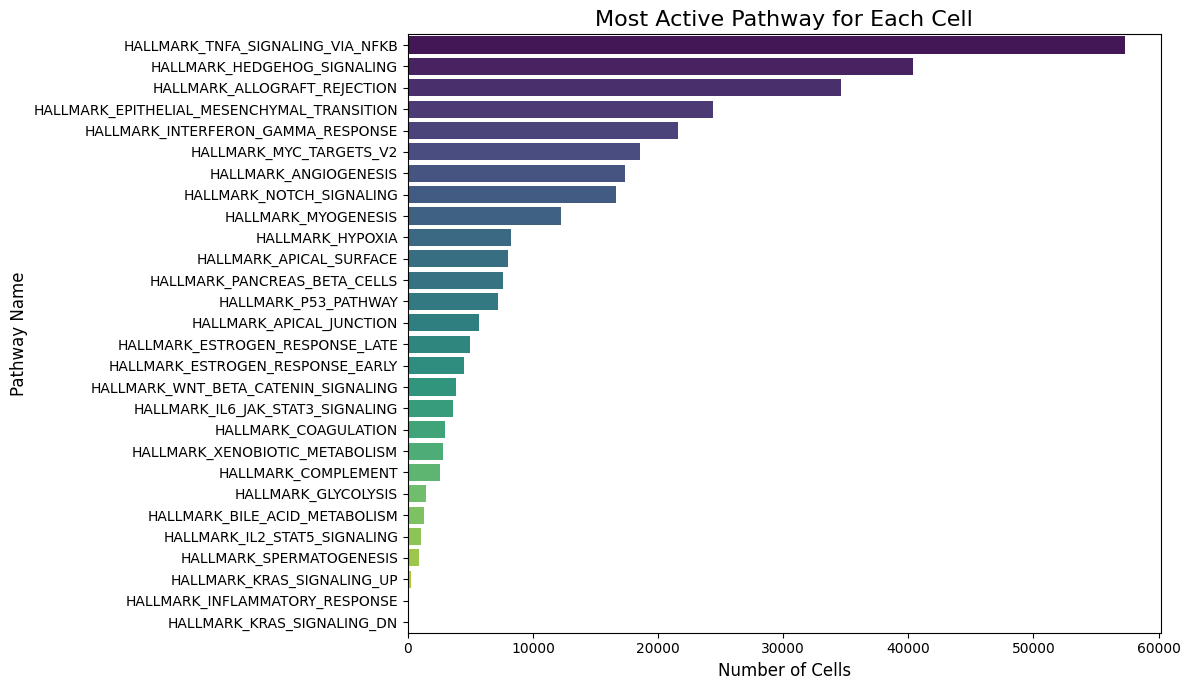


Analysis complete. The histogram above shows how many cells have each pathway as their highest-scoring pathway.

The second most popular pathway (as the second most active for cells) is: 'HALLMARK_TNFA_SIGNALING_VIA_NFKB' with 29260 cells.


/tmp/ipykernel_1928530/2374574550.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=second_most_active_pathways, order=pathway_counts.index, palette='viridis')


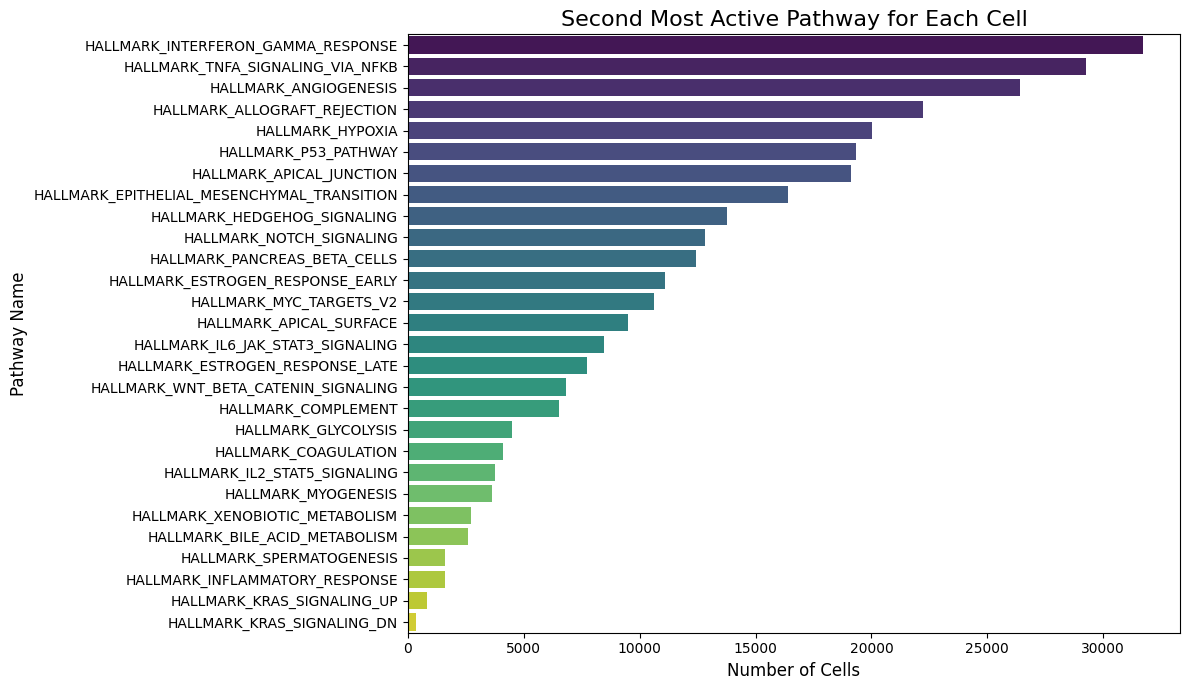


Analysis complete. The histogram above shows how many cells have each pathway as their second highest-scoring pathway.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_second_largest_pathway(row):
    if len(row) < 2: # Check if there are at least two pathways
        return np.nan # Or a placeholder for cells with fewer than 2 pathways
    return row.nlargest(2).index[-1]


# Use idxmax() along axis 1 (columns) to get the column name (pathway)
# that has the maximum value for each row (cell).
most_active_pathways = aucs_df.idxmax(axis=1)

# --- Determine and print the second most popular pathway ---
# Get the counts of each pathway being the most active, sorted in descending order
pathway_counts = most_active_pathways.value_counts()

if len(pathway_counts) >= 2:
    second_most_popular_pathway = pathway_counts.index[1]
    second_most_popular_count = pathway_counts.iloc[1]
    print(f"\nThe second most popular pathway (as the most active for cells) is: '{second_most_popular_pathway}' with {second_most_popular_count} cells.")
elif len(pathway_counts) == 1:
    print("\nThere is only one pathway that is the most active across all cells, so no second most popular pathway.")
else:
    print("\nNo pathways found as most active for any cell.")


# --- Visualize the results in a histogram (bar plot) ---
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability

# Create a count plot (histogram for categorical data)
sns.countplot(y=most_active_pathways, order=pathway_counts.index, palette='viridis')

plt.title('Most Active Pathway for Each Cell', fontsize=16)
plt.xlabel('Number of Cells', fontsize=12)
plt.ylabel('Pathway Name', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nAnalysis complete. The histogram above shows how many cells have each pathway as their highest-scoring pathway.")

second_most_active_pathways = aucs_df.apply(get_second_largest_pathway, axis=1)

# Remove any NaN entries if some cells didn't have a second pathway
second_most_active_pathways = second_most_active_pathways.dropna()

# --- Determine and print the second most popular pathway overall (from the 'second most active' list) ---
# Get the counts of each pathway being the second most active, sorted in descending order
pathway_counts = second_most_active_pathways.value_counts()

if len(pathway_counts) >= 2:
    # The "second most popular" here means the pathway that appeared as the
    # second highest score most frequently across all cells.
    second_most_popular_from_second_active = pathway_counts.index[1]
    second_most_popular_count_from_second_active = pathway_counts.iloc[1]
    print(f"\nThe second most popular pathway (as the second most active for cells) is: '{second_most_popular_from_second_active}' with {second_most_popular_count_from_second_active} cells.")
elif len(pathway_counts) == 1:
    print("\nOnly one pathway was identified as the second most active across cells, so no second most popular pathway from this list.")
else:
    print("\nNo second most active pathways found for any cell, or all were dropped due to insufficient data.")


# --- Visualize the results in a histogram (bar plot) ---
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability

# Create a count plot (histogram for categorical data)
sns.countplot(y=second_most_active_pathways, order=pathway_counts.index, palette='viridis')

plt.title('Second Most Active Pathway for Each Cell', fontsize=16)
plt.xlabel('Number of Cells', fontsize=12)
plt.ylabel('Pathway Name', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nAnalysis complete. The histogram above shows how many cells have each pathway as their second highest-scoring pathway.")


In [ ]:
# import requests
# from bs4 import BeautifulSoup
# import time # Import time for rate limiting
# import os # Import os for file path handling

# def get_webpage_content(url):
#     """
#     Fetches the HTML content of a given URL and extracts the brief description.

#     Args:
#         url (str): The URL of the webpage to fetch.

#     Returns:
#         str: The extracted brief description, or an error message if the request or parsing fails.
#     """
#     try:
#         # Send a GET request to the URL
#         response = requests.get(url, timeout=10) # Added timeout
#         # Added a small delay to be polite to the server and avoid being blocked
#         time.sleep(0.1)

#         # Raise an HTTPError for bad responses (4xx or 5xx)
#         response.raise_for_status()

#         # Parse the HTML content using BeautifulSoup
#         soup = BeautifulSoup(response.text, 'html.parser')

#         # Find the <th> tag with the text "Brief description"
#         # Then find the next sibling <td> tag to get its text
#         brief_description_th = soup.find('th', string='Brief description')
#         if brief_description_th:
#             brief_description_td = brief_description_th.find_next_sibling('td')
#             if brief_description_td:
#                 return brief_description_td.get_text(strip=True)
#             else:
#                 return "Error: Could not find the <td> tag after 'Brief description'."
#         else:
#             return "Error: Could not find 'Brief description' header on the page."

#     except requests.exceptions.Timeout:
#         return f"Error: Request timed out for {url}"
#     except requests.exceptions.RequestException as e:
#         # Handle any request-related errors (e.g., network issues, invalid URL)
#         return f"Error fetching {url}: {e}"
#     except Exception as e:
#         # Handle any other unexpected errors during parsing
#         return f"Error parsing content from {url}: {e}"

# def process_gmt_content(gmt_data):
#     """
#     Reads GMT-like content, extracts URLs, and fetches brief descriptions for each.

#     Args:
#         gmt_data (str): A string containing the content of a .gmt file.
#                         Each line should have gene set name, URL, and then genes,
#                         separated by tabs or multiple spaces.
#     """
#     results = []
#     lines = gmt_data.strip().split('\n')
#     for line in lines:
#         parts = line.strip().split('\t') # Split by tab
#         if len(parts) >= 2: # Ensure at least name and URL are present
#             gene_set_name = parts[0].strip()
#             url = parts[1].strip()
#             print(f"Fetching description for: {gene_set_name} (URL: {url})")
#             description = get_webpage_content(url)
#             results.append(f"{gene_set_name}: {description}")
#         else:
#             results.append(f"Skipping malformed line: {line}")
#     return "\n".join(results)


# if __name__ == "__main__":
#     # Specify the name of your .gmt file
#     gmt_filename = "/kaggle/input/pathways-50/h.all.v2025.1.Hs.symbols.gmt" # You can change this to your file's name

#     if os.path.exists(gmt_filename):
#         try:
#             with open(gmt_filename, 'r') as f:
#                 gmt_file_content = f.read()

#             print(f"Starting to process GMT content from {gmt_filename}...")
#             processed_results = process_gmt_content(gmt_file_content)
#             print("\n--- Processing Complete ---")
#             print(processed_results)

#         except Exception as e:
#             print(f"Error reading or processing the file '{gmt_filename}': {e}")
#     else:
#         print(f"Error: The file '{gmt_filename}' was not found.")
#         print("Please make sure the .gmt file is in the same directory as this script, or provide the full path.")
#         # Fallback to the example content if file not found, for demonstration purposes
#         print("\n--- Processing example content instead ---")
#         gmt_file_content_example = """
# ABBUD_LIF_SIGNALING_1_DN	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_1_DN	AHNAK	ALCAM	ANKRD40	ARID1A	BCKDHB	C16orf89	CAPN9	CD24	CYFIP1	DCAF11	DDC	EFNA2	ENPP2	FOXA2	GRIA2	HK2	HOXC9	ITGA6	KLRB1	LIMS1	MTSS2	OSTF1	PELI1	REXO2	STEEP1	SUCLA2	SYTL4	TSPAN7
# ABBUD_LIF_SIGNALING_1_UP	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_1_UP	ACAA2	ALDOC	ANXA8L1	BCL3	CEBPB	CXCL14	CYB561	ELF3	FBP1	FGG	GPCPD1	GPX3	GRAMD2B	HAS1	IL1R1	IRF1	KLF10	KNG1	LBP	LCN2	LRG1	MAN1A1	MPO	NMI	PSMB8	PTPN1	RASA3	RGS4	RHOU	RNASE2	SCT	SOCS3	SQOR	ST3GAL1	STAT3	TAPBP	TMEM176A	TMEM176B	TNFRSF1A	TSPAN4	UPP1	VWF	XBP1
# ABBUD_LIF_SIGNALING_2_DN	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_2_DN	CGA	CITED2	NALCN	PITX2	PTHLH	SCN1A	ZNF280D
# ABBUD_LIF_SIGNALING_2_UP	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_2_UP	ATP1B1	COL11A1	DAB2	DCN	DIO2	EZR	FGFR1	GPX2	JUNB	NRP1	PFKP	PPP2R2B	PTPRO
# ABDELMOHSEN_ELAVL4_TARGETS	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABDELMOHSEN_ELAVL4_TARGETS	BCL2	CAB39	CASP3	CDC42	CDH2	DLG4	EIF2AK2	ITGA1	ITGB1	KCNQ2	KMT5A	LEPROTL1	NCAM1	PARP1	RAB10	RHOA
# ABDULRAHMAN_KIDNEY_CANCER_VHL_DN	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABDULRAHMAN_KIDNEY_CANCER_VHL_DN	ACTA2	ALDH1A1	ALDH3B1	ITGB3BP	MPPE1	MTMR3	PALLD	PJA2	RHOBTB1	SEC31A	SNRPN	STX11	UGT2B7
#         """
#         processed_results = process_gmt_content(gmt_file_content_example)
#         print(processed_results)


Starting to process GMT content from /kaggle/input/pathways-50/h.all.v2025.1.Hs.symbols.gmt...
Fetching description for: HALLMARK_ADIPOGENESIS (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ADIPOGENESIS)
Fetching description for: HALLMARK_ALLOGRAFT_REJECTION (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ALLOGRAFT_REJECTION)
Fetching description for: HALLMARK_ANDROGEN_RESPONSE (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ANDROGEN_RESPONSE)
Fetching description for: HALLMARK_ANGIOGENESIS (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ANGIOGENESIS)
Fetching description for: HALLMARK_APICAL_JUNCTION (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_APICAL_JUNCTION)
Fetching description for: HALLMARK_APICAL_SURFACE (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_APICAL_SURFACE)
Fetching description for: HALLMARK_APOPTOSIS (URL: https://www.gsea-msigdb.org/gsea/m

In [87]:
import sys
import gc

del ex_matrix 
del rnk_mtx 
del aucs_df 
del filtered_aucs

gc.collect()
# Get all objects in current namespace
all_vars = {name: obj for name, obj in globals().items()
           if not name.startswith('_') and not callable(obj)}

# Sort by memory size
sorted_vars = sorted(all_vars.items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)

print("Variable Memory Usage (sorted by size):")
print("-" * 40)
for name, obj in sorted_vars:
    size = sys.getsizeof(obj)
    print(f"{name}: {size} bytes ({type(obj).__name__})")

Variable Memory Usage (sorted by size):
----------------------------------------
adata: 408140024 bytes (AnnData)
second_most_active_pathways: 6253787 bytes (Series)
most_active_pathways: 6067538 bytes (Series)
top5_percentile_mask: 5105968 bytes (DataFrame)
auc_scores: 3945125 bytes (DataFrame)
gmt_file_content: 48738 bytes (str)
pathway_frequencies: 6705 bytes (Series)
processed_results: 4686 bytes (str)
pathway_counts: 3400 bytes (Series)
selected_pathways: 1717 bytes (Index)
all_vars: 1584 bytes (dict)
In: 792 bytes (list)
signatures: 472 bytes (list)
aucs: 472 bytes (list)
signature_names: 472 bytes (list)
sorted_vars: 408 bytes (list)
Out: 224 bytes (dict)
f: 208 bytes (TextIOWrapper)
GMT_FNAME: 103 bytes (str)
gmt_filename: 103 bytes (str)
path: 90 bytes (str)
second_most_popular_pathway: 81 bytes (str)
output_filename: 77 bytes (str)
second_most_popular_from_second_active: 77 bytes (str)
sc: 72 bytes (module)
os: 72 bytes (module)
anndata: 72 bytes (module)
pd: 72 bytes (module